## Load Dataset

In [122]:
import sys
from utils.timer import Timer
sys.path.append('.')

import pandas as pd

import numpy as np

import math

from sklearn.cluster import KMeans

from scipy.spatial.distance import euclidean


from utils.kmeans_evaluation import evaluate_kmeans_overlap,visualize
from utils.comparison import visualize_comparison

from structures.grid import Grid

from structures.r_tree_analyzer import RTreeSpatialAnalyzer

import matplotlib.pyplot as plt
import matplotlib.patches as patches

%matplotlib inline
csv_file_path = "./datasets/normal_coords_2.csv"

In [123]:
csv_data = pd.read_csv(csv_file_path)
# latitudes = csv_data["latitude"]
# longitudes = csv_data["longitude"]
latitudes = csv_data["latitude"]
longitudes = csv_data["longitude"]

maxLatitude = latitudes.max()
minLatitude = latitudes.min()
minLatitude = math.floor(minLatitude)
maxLatitude = math.ceil(maxLatitude)

maxLongitude = longitudes.max()
maxLongitude = math.ceil(maxLongitude)

minLongtitude = longitudes.min()
minLongtitude = math.floor(minLongtitude)

points_array = np.column_stack((longitudes, latitudes))
# initiate KMEANS
kmeans_data = csv_data[["longitude", "latitude"]].to_numpy()


## KMEANS Evaluation

In [124]:
kmeans_timer = Timer()
kmeans_timer.start()
kmeans_results= evaluate_kmeans_overlap(
    kmeans_data, n_clusters=7
)
kmeans_timer.stop()
print(kmeans_timer._time_elapsed)
# print("KMEANS Score:", kmeans_results)

0.021866229999432107


## Grid Evalution

In [125]:
grid_timer = Timer()
grid_timer.start()
grid = Grid(
        xmin=minLongtitude, ymin=minLatitude, xmax=maxLongitude, ymax=maxLatitude, m=20
    )
    # assign points to grid
grid.fit(zip(csv_data["longitude"], csv_data["latitude"]))
grid_timer.stop()
print(grid_timer._time_elapsed)
print(f"Grid Score: {grid.compute_grid_overlap()}")


0.006643998000072315
Grid Score: 2.0269809427455554


In [126]:
print(grid.get_clusters())

['C1(K=[-3.8, -1.3999999999999997], r=0.28)', 'C2(K=[-3.8, -0.9999999999999998], r=0.23)', 'C3(K=[-3.8, -0.5999999999999999], r=0.13)', 'C4(K=[-3.4000000000000004, -2.2], r=0.13)', 'C5(K=[-3.4000000000000004, -1.7999999999999998], r=0.22)', 'C6(K=[-3.4000000000000004, -0.9999999999999998], r=0.09)', 'C7(K=[-3.4000000000000004, 1.0000000000000004], r=0.22)', 'C8(K=[-3.0, -0.9999999999999998], r=0.13)', 'C9(K=[-3.0, -0.19999999999999996], r=0.12)', 'C10(K=[-3.0, 0.20000000000000018], r=0.10)', 'C11(K=[-2.5999999999999996, -2.5999999999999996], r=0.13)', 'C12(K=[-2.5999999999999996, -1.7999999999999998], r=0.21)', 'C13(K=[-2.5999999999999996, -1.3999999999999997], r=0.14)', 'C14(K=[-2.5999999999999996, -0.9999999999999998], r=0.15)', 'C15(K=[-2.5999999999999996, -0.5999999999999999], r=0.13)', 'C16(K=[-2.5999999999999996, -0.19999999999999996], r=0.21)', 'C17(K=[-2.5999999999999996, 0.20000000000000018], r=0.21)', 'C18(K=[-2.5999999999999996, 0.6000000000000005], r=0.08)', 'C19(K=[-2.5999

## R Tree Evaluation

In [127]:

r_tree_timer = Timer()
r_tree_timer.start()
analyzer = RTreeSpatialAnalyzer()
if analyzer.load_data_from_csv(csv_file_path,required_cols=['latitude','longitude']):
    r_tree_timer.stop()
    print(r_tree_timer._time_elapsed)
    leaf_clusters = analyzer.get_leaf_mbrs()

    # Compute Overlap on the clusters
    r_tree_overlap = analyzer.compute_mbr_overlap(leaf_clusters)
    print(f"Total Cluster Overlap Area: {r_tree_overlap:.4f}")

R-tree built with 1000 entries.
0.038491606999741634
Extracted 14 Leaf MBRs from R-tree.
Total Cluster Overlap Area: 70.2678


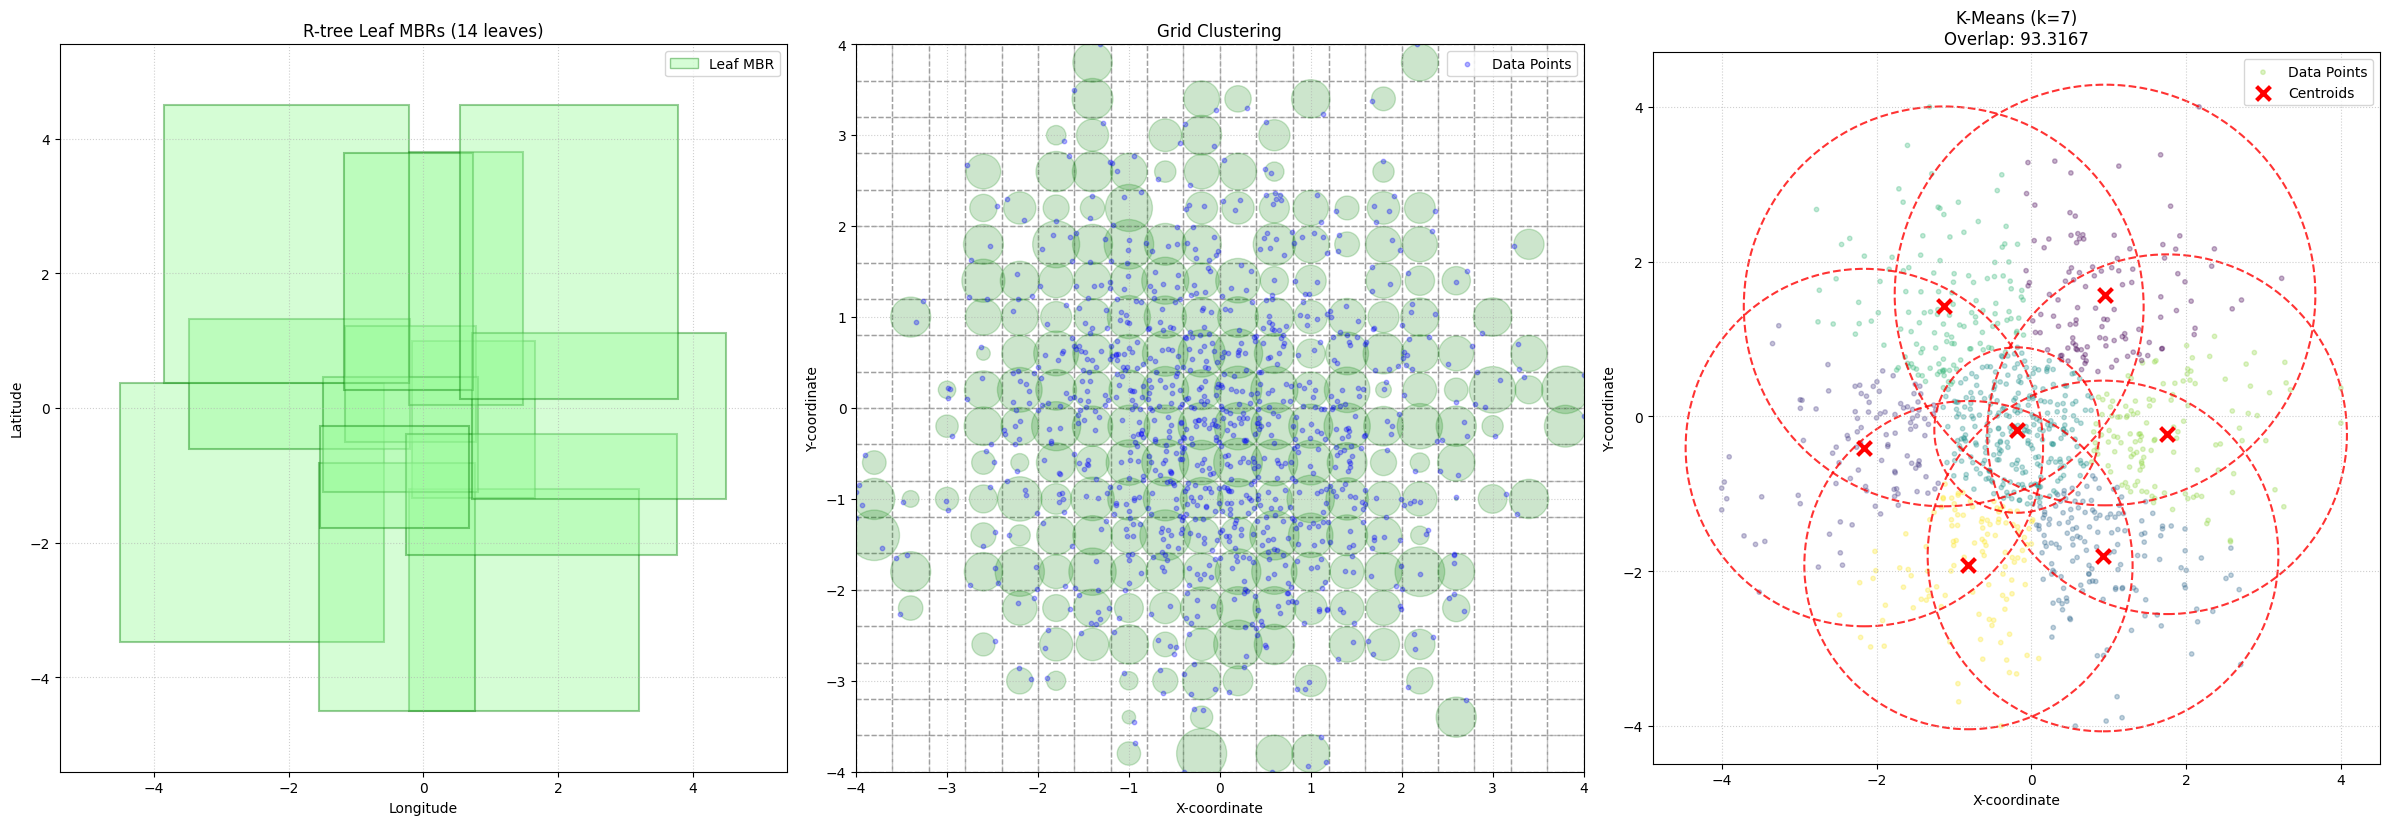

In [128]:
visualize_comparison(leaf_clusters, grid, kmeans_data, kmeans_results)

In [129]:
grid_overlap = grid.compute_grid_overlap()
kmeans_overlap, labels, centers, radii = kmeans_results

algorithm_details = [
    {
        "Algorithm": "KMEANS",
        "Overlap Score": kmeans_overlap,
        "Parameters": "n_clusters=7",
        "Execution Time": kmeans_timer._time_elapsed,
    },
    {
        "Algorithm": "Grid",
        "Overlap Score": grid_overlap,
        "Parameters": "m=20",
        "Execution Time": grid_timer._time_elapsed,
    },
    {
        "Algorithm": "R-Tree",
        "Overlap Score": r_tree_overlap,
        "Parameters": "-",
        "Execution Time": r_tree_timer._time_elapsed,
    },
]

import pandas as pd

comparison_df = pd.DataFrame(algorithm_details)
display(comparison_df)

,Algorithm,Overlap Score,Parameters,Execution Time
0,KMEANS,93.316747,n_clusters=7,0.021866
1,Grid,2.026981,m=20,0.006644
2,R-Tree,70.267846,-,0.038492
